# Exploratory Data Analysis for the Book-Crossing Graph Recommendation System

This notebook performs a complete exploratory data analysis of the Book-Crossing dataset using `Books.csv`, `Ratings.csv`, and `Users.csv`.

The goal is to understand data quality, user and book behavior, rating patterns, and graph structure so the data can be prepared for a graph-based recommendation model such as LightGCN or a related bipartite recommender.

Each section explains what is being analyzed, why it matters, and what to look for in the plots and tables.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='notebook', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 120


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data' / 'raw-dataset-books').exists():
            return candidate
    raise FileNotFoundError('Could not locate the project root containing data/raw-dataset-books.')


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'data' / 'raw-dataset-books'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BOOKS_PATH = DATA_DIR / 'Books.csv'
RATINGS_PATH = DATA_DIR / 'Ratings.csv'
USERS_PATH = DATA_DIR / 'Users.csv'

assert BOOKS_PATH.exists(), f'Missing file: {BOOKS_PATH}'
assert RATINGS_PATH.exists(), f'Missing file: {RATINGS_PATH}'
assert USERS_PATH.exists(), f'Missing file: {USERS_PATH}'

books_raw = pd.read_csv(BOOKS_PATH, low_memory=False)
ratings_raw = pd.read_csv(RATINGS_PATH, low_memory=False)
users_raw = pd.read_csv(USERS_PATH, low_memory=False)

books = books_raw.copy()
ratings = ratings_raw.copy()
users = users_raw.copy()


def section_title(title: str) -> None:
    print('\n' + '=' * 100)
    print(title)
    print('=' * 100)


def save_current_fig(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=160, bbox_inches='tight')


def clean_publication_year(series: pd.Series) -> pd.Series:
    years = pd.to_numeric(series, errors='coerce')
    current_year = pd.Timestamp.today().year
    valid_years = years.where(years.between(1450, current_year))
    return valid_years


def clean_age(series: pd.Series) -> pd.Series:
    ages = pd.to_numeric(series, errors='coerce')
    return ages.where(ages.between(5, 100))


def extract_country(location: pd.Series) -> pd.Series:
    country = location.fillna('Unknown').astype(str).str.split(',').str[-1].str.strip()
    country = country.replace({'': 'Unknown', 'nan': 'Unknown', 'None': 'Unknown'})
    return country.str.title()


def top_counts(series: pd.Series, n: int = 10) -> pd.DataFrame:
    counts = series.value_counts().head(n).reset_index()
    counts.columns = [series.name or 'value', 'count']
    return counts


books['Year-Of-Publication_Clean'] = clean_publication_year(books['Year-Of-Publication'])
users['Age_Clean'] = clean_age(users['Age'])
users['Country'] = extract_country(users['Location'])
ratings['Book-Rating'] = pd.to_numeric(ratings['Book-Rating'], errors='coerce')

## Sections 1 and 2: Dataset Overview and Data Quality Assessment

This part loads the raw CSV files and checks whether the data is complete, consistent, and suitable for analysis.

Why this matters:
- Recommendation models are sensitive to missing or inconsistent keys.
- Graph construction depends on clean user and book identifiers.
- Invalid ages, years, or ratings can distort statistics and learned embeddings.


1. Dataset Overview

Books dataset
Shape: (271360, 8)
Columns: ['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L']
Data types:


,dtype
ISBN,str
Book-Title,str
Book-Author,str
Year-Of-Publication,str
Publisher,str
Image-URL-S,str
Image-URL-M,str
Image-URL-L,str


First rows:


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


Last rows:


...

Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User-ID,278858.0,NaN,NaN,NaN,139429.5,80499.51502,1.0,69715.25,139429.5,209143.75,278858.0
Location,278858,57339,"london, england, united kingdom",2506,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,168096.0,NaN,NaN,NaN,34.751434,14.428097,0.0,24.0,32.0,44.0,244.0



2. Data Quality Assessment


,dataset,rows,columns,missing_values,duplicate_rows
0,Books,271360,8,7,0
1,Ratings,1149780,3,0,0
2,Users,278858,3,110762,0


,check,count
0,Invalid publication years,4631
1,Missing age values,110762
2,Unrealistic ages,1248
3,Out-of-range ratings,0
4,Ratings with missing book references,118644
5,Ratings with missing user references,0


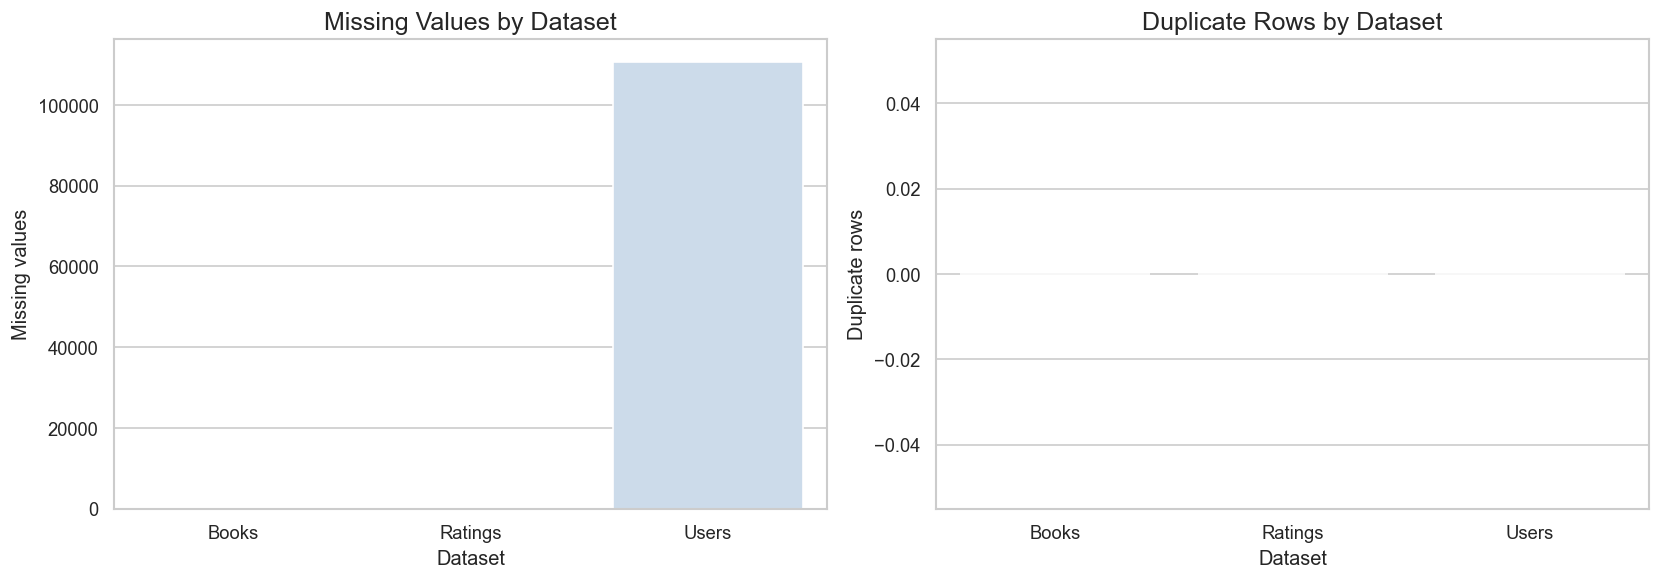

Observations:
- Book data is usually the cleanest structurally, while users data often contains missing ages.
- Ratings data should be checked carefully for foreign-key consistency because graph construction depends on valid user-book pairs.
- Invalid years, ages, or ratings should be filtered before feature engineering and graph creation.


In [2]:
section_title('1. Dataset Overview')

datasets = {
    'Books': books_raw,
    'Ratings': ratings_raw,
    'Users': users_raw,
}

for name, df in datasets.items():
    print(f'\n{name} dataset')
    print(f'Shape: {df.shape}')
    print('Columns:', list(df.columns))
    print('Data types:')
    display(df.dtypes.to_frame('dtype'))
    print('First rows:')
    display(df.head())
    print('Last rows:')
    display(df.tail())
    print('Summary statistics:')
    display(df.describe(include='all').T)

section_title('2. Data Quality Assessment')

quality_summary = pd.DataFrame({
    'dataset': ['Books', 'Ratings', 'Users'],
    'rows': [len(books_raw), len(ratings_raw), len(users_raw)],
    'columns': [books_raw.shape[1], ratings_raw.shape[1], users_raw.shape[1]],
    'missing_values': [books_raw.isna().sum().sum(), ratings_raw.isna().sum().sum(), users_raw.isna().sum().sum()],
    'duplicate_rows': [books_raw.duplicated().sum(), ratings_raw.duplicated().sum(), users_raw.duplicated().sum()],
})

display(quality_summary)

book_year_raw = pd.to_numeric(books_raw['Year-Of-Publication'], errors='coerce')
user_age_raw = pd.to_numeric(users_raw['Age'], errors='coerce')
rating_values_raw = pd.to_numeric(ratings_raw['Book-Rating'], errors='coerce')

invalid_year_mask = book_year_raw.notna() & ~book_year_raw.between(1450, pd.Timestamp.today().year)
invalid_age_mask = user_age_raw.notna() & ~user_age_raw.between(5, 100)
invalid_rating_mask = rating_values_raw.notna() & ~rating_values_raw.between(0, 10)

integrity_summary = pd.DataFrame({
    'check': [
        'Invalid publication years',
        'Missing age values',
        'Unrealistic ages',
        'Out-of-range ratings',
        'Ratings with missing book references',
        'Ratings with missing user references',
    ],
    'count': [
        invalid_year_mask.sum(),
        user_age_raw.isna().sum(),
        invalid_age_mask.sum(),
        invalid_rating_mask.sum(),
        (~ratings_raw['ISBN'].isin(books_raw['ISBN'])).sum(),
        (~ratings_raw['User-ID'].isin(users_raw['User-ID'])).sum(),
    ],
})

display(integrity_summary)

missing_counts = quality_summary.set_index('dataset')['missing_values']
duplicate_counts = quality_summary.set_index('dataset')['duplicate_rows']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=missing_counts.index, y=missing_counts.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Missing Values by Dataset')
axes[0].set_xlabel('Dataset')
axes[0].set_ylabel('Missing values')

sns.barplot(x=duplicate_counts.index, y=duplicate_counts.values, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Duplicate Rows by Dataset')
axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('Duplicate rows')

save_current_fig('dataset_quality_overview.png')
plt.show()

print('Observations:')
print('- Book data is usually the cleanest structurally, while users data often contains missing ages.')
print('- Ratings data should be checked carefully for foreign-key consistency because graph construction depends on valid user-book pairs.')
print('- Invalid years, ages, or ratings should be filtered before feature engineering and graph creation.')

## Sections 3 to 5: Books, Users, and Ratings Analysis

This block studies each dataset separately.

- The books analysis shows the catalog structure, publication trends, and the most frequent authors and publishers.
- The users analysis focuses on age quality, location information, and country-level user distribution.
- The ratings analysis reveals the interaction pattern between users and books, including explicit and implicit feedback.

These analyses are important because they reveal sparsity, popularity bias, and demographic patterns that shape recommendation quality.


3. Books Dataset Analysis


,metric,value
0,Unique books,271360
1,Valid publication years,266726
2,Invalid publication years,4634


,Book-Author,count
0,Agatha Christie,632
1,William Shakespeare,567
2,Stephen King,524
3,Ann M. Martin,423
4,Carolyn Keene,373
5,Francine Pascal,372
6,Isaac Asimov,330
7,Nora Roberts,315
8,Barbara Cartland,307
9,Charles Dickens,302


,Publisher,count
0,Harlequin,7535
1,Silhouette,4220
2,Pocket,3905
3,Ballantine Books,3783
4,Bantam Books,3646
5,Scholastic,3160
6,Simon &amp; Schuster,2971
7,Penguin Books,2844
8,Berkley Publishing Group,2771
9,Warner Books,2727


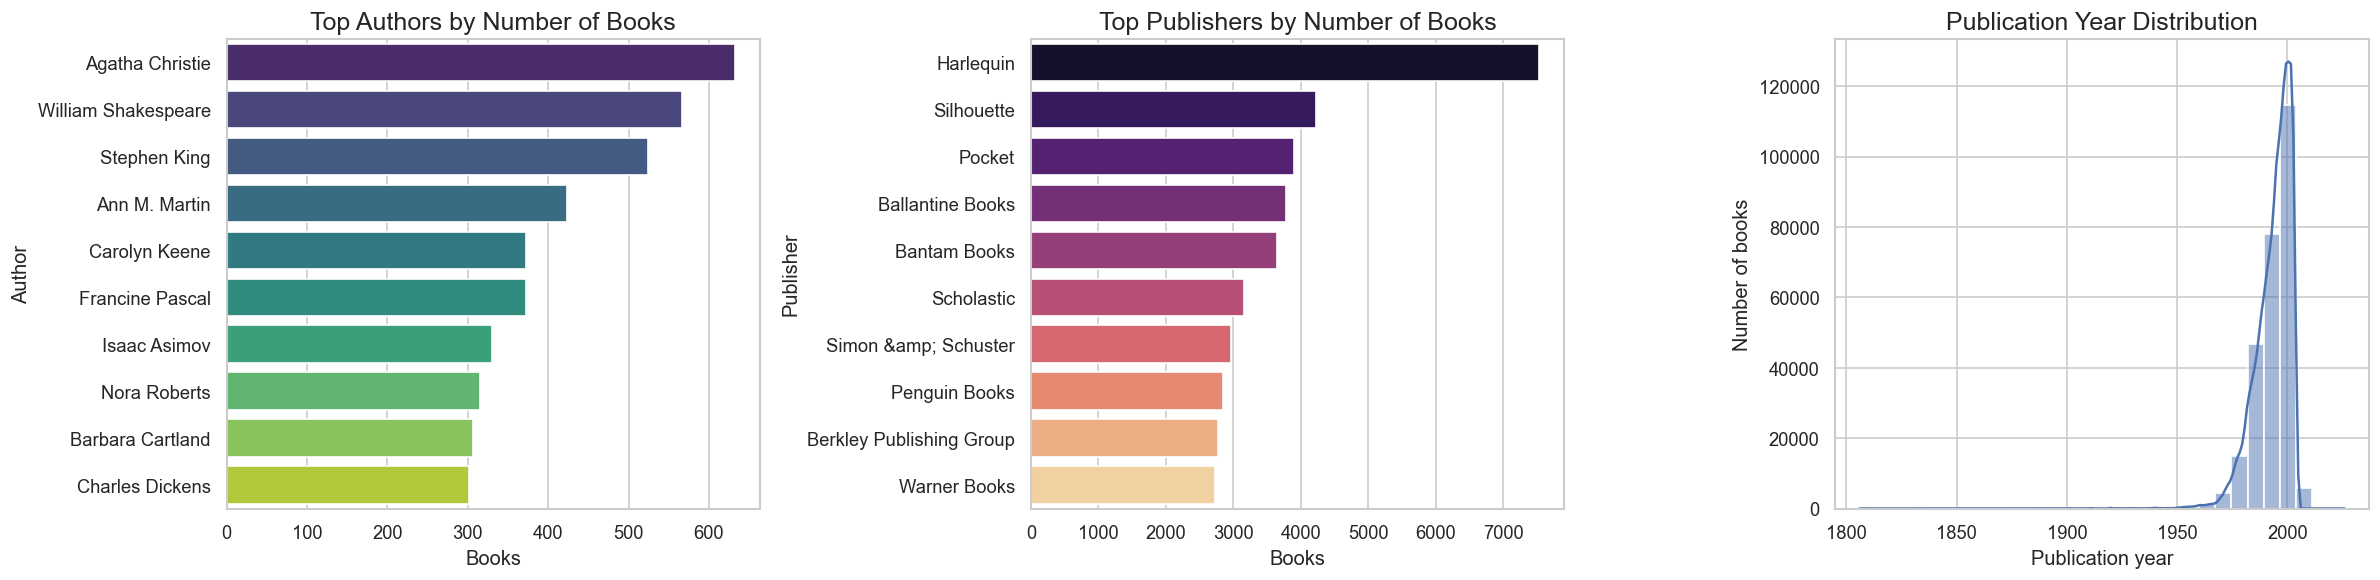

Books section insights:
- The catalog contains 271,360 unique ISBNs.
- A small number of publication years are invalid or missing and should be excluded from modeling.
- Author and publisher counts usually show a long-tail pattern, which means a few names dominate the catalog.

4. Users Dataset Analysis


,metric,value
0,Unique users,278858
1,Missing ages,110762
2,Unrealistic ages,1248
3,Valid ages,166848


,Country,count
0,Usa,139711
1,Canada,21658
2,United Kingdom,18538
3,Germany,17043
4,Spain,13147
5,Australia,11784
6,Italy,11266
7,Unknown,4579
8,France,3455
9,Portugal,3325


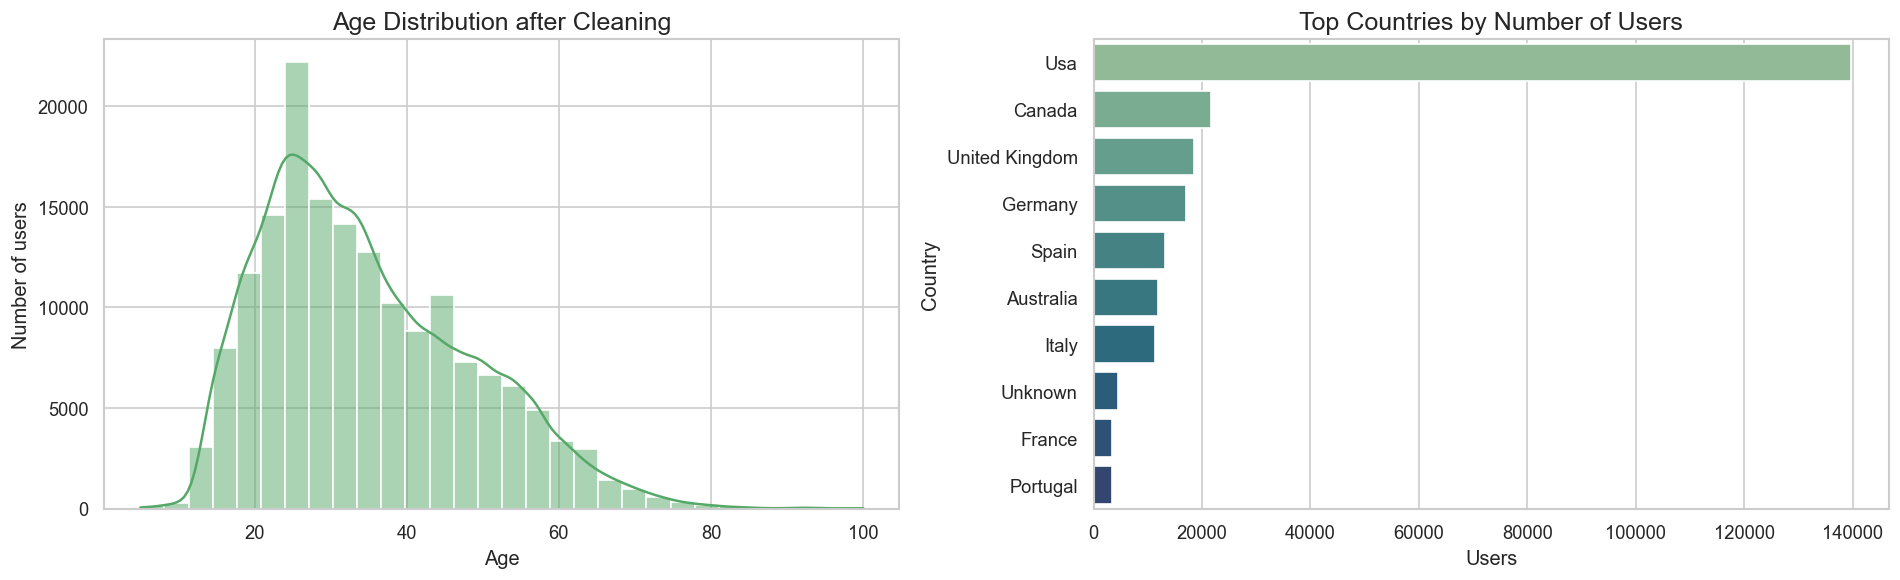

Users section insights:
 - Missing ages and unrealistic ages should be handled before demographic analysis.
 - Location parsing provides a useful country-level signal for regional preference analysis.
 - Country distribution often shows concentration in a few regions, which can affect popularity bias.

5. Ratings Dataset Analysis


,metric,value
0,Total ratings,1149780
1,Implicit ratings (0),716109
2,Explicit ratings (1-10),433671


,User-ID,count
0,11676,13602
1,198711,7550
2,153662,6109
3,98391,5891
4,35859,5850
5,212898,4785
6,278418,4533
7,76352,3367
8,110973,3100
9,235105,3067


,ISBN,count
0,0971880107,2502
1,0316666343,1295
2,0385504209,883
3,0060928336,732
4,0312195516,723
5,044023722X,647
6,0679781587,639
7,0142001740,615
8,067976402X,614
9,0671027360,586


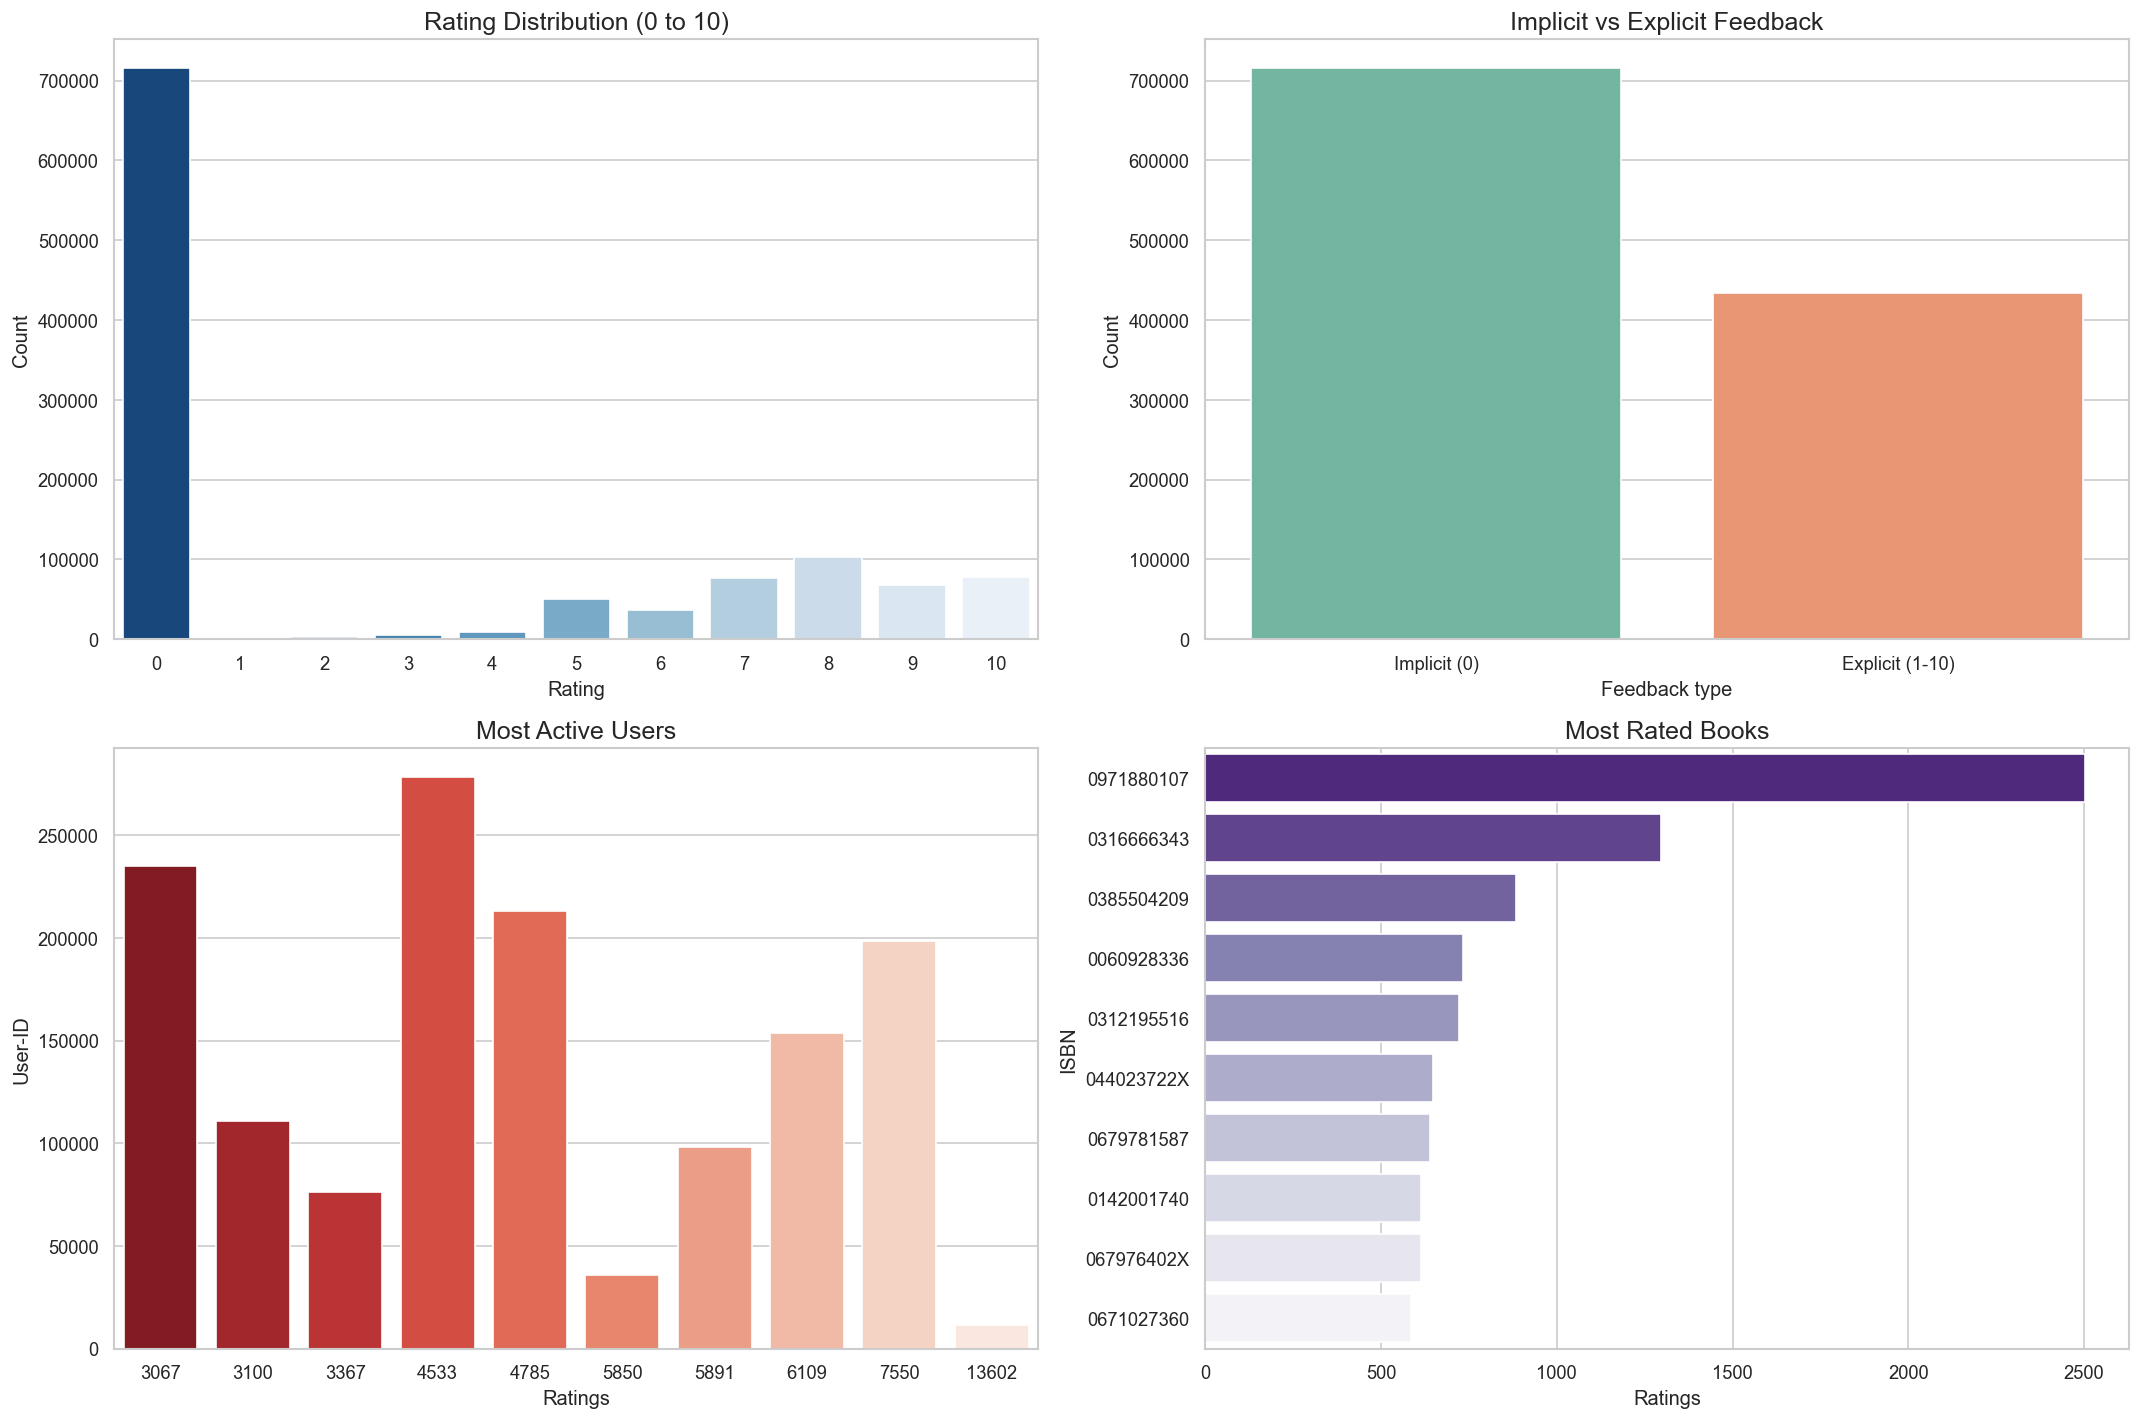

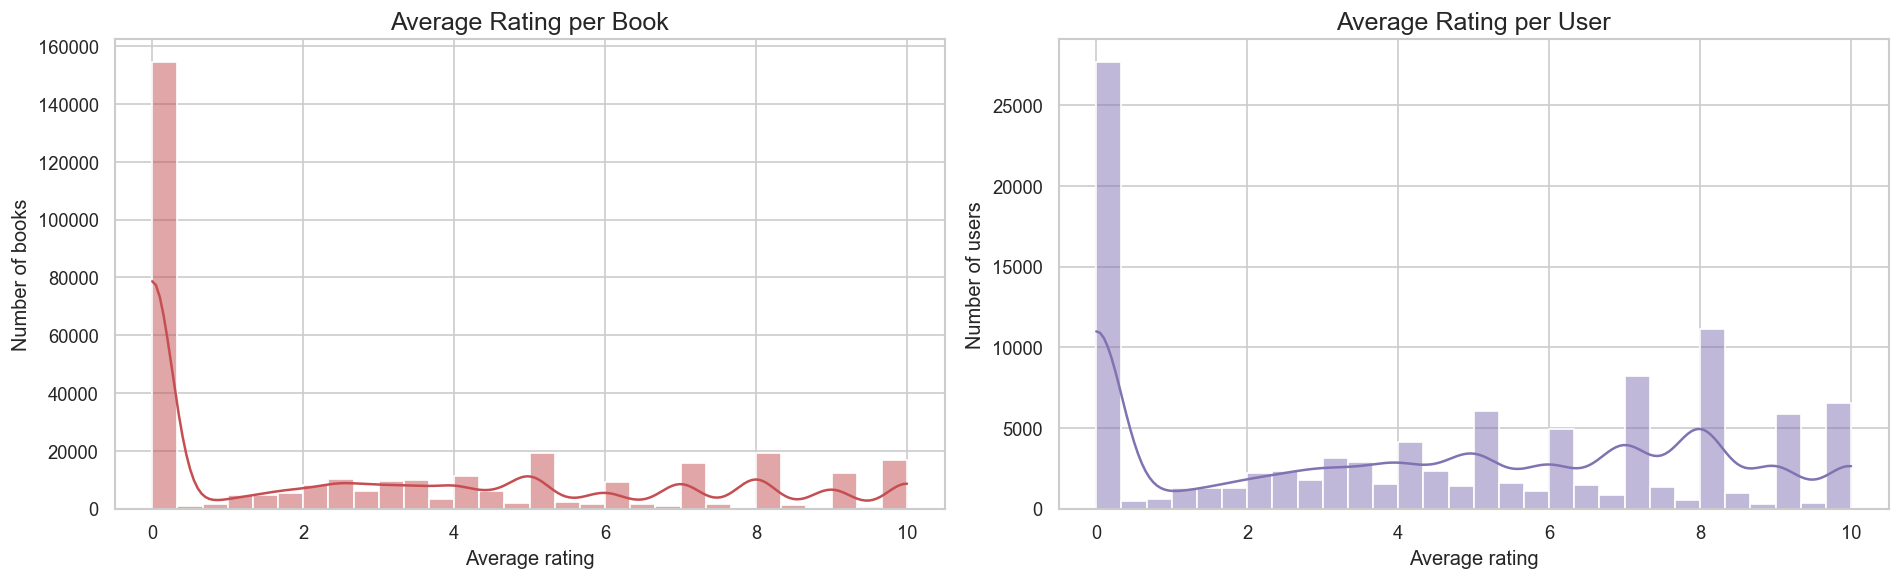

Ratings section insights:
- Ratings are dominated by explicit or implicit feedback depending on the number of zero ratings: 716,109 implicit vs 433,671 explicit.
- Popularity is likely skewed because some books receive far more ratings than others.
- User-level and book-level averages help identify highly engaged users and consistently appreciated books.


In [3]:
section_title('3. Books Dataset Analysis')

books_clean = books.copy()
unique_books = books_clean['ISBN'].nunique()
valid_years = books_clean['Year-Of-Publication_Clean'].dropna()
invalid_year_count = books_clean['Year-Of-Publication'].notna().sum() - books_clean['Year-Of-Publication_Clean'].notna().sum()

top_authors_df = top_counts(books_clean['Book-Author'], 10)
top_publishers_df = top_counts(books_clean['Publisher'], 10)

book_summary = pd.DataFrame({
    'metric': ['Unique books', 'Valid publication years', 'Invalid publication years'],
    'value': [unique_books, len(valid_years), invalid_year_count],
})
display(book_summary)
display(top_authors_df)
display(top_publishers_df)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(data=top_authors_df, y='Book-Author', x='count', ax=axes[0], palette='viridis')
axes[0].set_title('Top Authors by Number of Books')
axes[0].set_xlabel('Books')
axes[0].set_ylabel('Author')

sns.barplot(data=top_publishers_df, y='Publisher', x='count', ax=axes[1], palette='magma')
axes[1].set_title('Top Publishers by Number of Books')
axes[1].set_xlabel('Books')
axes[1].set_ylabel('Publisher')

sns.histplot(valid_years, bins=30, kde=True, ax=axes[2], color='#4C72B0')
axes[2].set_title('Publication Year Distribution')
axes[2].set_xlabel('Publication year')
axes[2].set_ylabel('Number of books')

save_current_fig('books_analysis.png')
plt.show()

print('Books section insights:')
print(f'- The catalog contains {unique_books:,} unique ISBNs.')
print(f'- A small number of publication years are invalid or missing and should be excluded from modeling.')
print('- Author and publisher counts usually show a long-tail pattern, which means a few names dominate the catalog.')

section_title('4. Users Dataset Analysis')

users_clean = users.copy()
unique_users = users_clean['User-ID'].nunique()
missing_age_count = users_clean['Age'].isna().sum()
age_numeric = pd.to_numeric(users_clean['Age'], errors='coerce')
unrealistic_age_count = age_numeric.notna().sum() - age_numeric.between(5, 100).sum()
valid_ages = users_clean['Age_Clean'].dropna()
country_counts_df = users_clean['Country'].value_counts().head(10).reset_index()
country_counts_df.columns = ['Country', 'count']

user_summary = pd.DataFrame({
    'metric': ['Unique users', 'Missing ages', 'Unrealistic ages', 'Valid ages'],
    'value': [unique_users, missing_age_count, unrealistic_age_count, len(valid_ages)],
})
display(user_summary)
display(country_counts_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(valid_ages, bins=30, kde=True, ax=axes[0], color='#55A868')
axes[0].set_title('Age Distribution after Cleaning')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of users')

sns.barplot(data=country_counts_df, y='Country', x='count', ax=axes[1], palette='crest')
axes[1].set_title('Top Countries by Number of Users')
axes[1].set_xlabel('Users')
axes[1].set_ylabel('Country')

save_current_fig('users_analysis.png')
plt.show()

print('Users section insights:')
print(' - Missing ages and unrealistic ages should be handled before demographic analysis.')
print(' - Location parsing provides a useful country-level signal for regional preference analysis.')
print(' - Country distribution often shows concentration in a few regions, which can affect popularity bias.')

section_title('5. Ratings Dataset Analysis')

ratings_clean = ratings.copy()
ratings_clean = ratings_clean.loc[ratings_clean['Book-Rating'].between(0, 10)].copy()
total_ratings = len(ratings_clean)
implicit_count = int((ratings_clean['Book-Rating'] == 0).sum())
explicit_count = int((ratings_clean['Book-Rating'] > 0).sum())

most_active_users_df = ratings_clean['User-ID'].value_counts().head(10).reset_index()
most_active_users_df.columns = ['User-ID', 'count']
most_rated_books_df = ratings_clean['ISBN'].value_counts().head(10).reset_index()
most_rated_books_df.columns = ['ISBN', 'count']
avg_rating_per_book = ratings_clean.groupby('ISBN')['Book-Rating'].agg(['mean', 'count']).sort_values(['count', 'mean'], ascending=[False, False])
avg_rating_per_user = ratings_clean.groupby('User-ID')['Book-Rating'].agg(['mean', 'count']).sort_values(['count', 'mean'], ascending=[False, False])

ratings_summary = pd.DataFrame({
    'metric': ['Total ratings', 'Implicit ratings (0)', 'Explicit ratings (1-10)'],
    'value': [total_ratings, implicit_count, explicit_count],
})
display(ratings_summary)
display(most_active_users_df)
display(most_rated_books_df)

a = ratings_clean['Book-Rating'].value_counts().sort_index().reset_index()
a.columns = ['Book-Rating', 'count']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.barplot(data=a, x='Book-Rating', y='count', ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Rating Distribution (0 to 10)')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Count')

feedback_df = pd.DataFrame({
    'type': ['Implicit (0)', 'Explicit (1-10)'],
    'count': [implicit_count, explicit_count],
})
sns.barplot(data=feedback_df, x='type', y='count', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Implicit vs Explicit Feedback')
axes[0, 1].set_xlabel('Feedback type')
axes[0, 1].set_ylabel('Count')

sns.barplot(data=most_active_users_df, x='count', y='User-ID', ax=axes[1, 0], palette='Reds_r')
axes[1, 0].set_title('Most Active Users')
axes[1, 0].set_xlabel('Ratings')
axes[1, 0].set_ylabel('User-ID')

sns.barplot(data=most_rated_books_df, x='count', y='ISBN', ax=axes[1, 1], palette='Purples_r')
axes[1, 1].set_title('Most Rated Books')
axes[1, 1].set_xlabel('Ratings')
axes[1, 1].set_ylabel('ISBN')

save_current_fig('ratings_analysis.png')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(avg_rating_per_book['mean'], bins=30, kde=True, ax=axes[0], color='#C44E52')
axes[0].set_title('Average Rating per Book')
axes[0].set_xlabel('Average rating')
axes[0].set_ylabel('Number of books')

sns.histplot(avg_rating_per_user['mean'], bins=30, kde=True, ax=axes[1], color='#8172B2')
axes[1].set_title('Average Rating per User')
axes[1].set_xlabel('Average rating')
axes[1].set_ylabel('Number of users')

save_current_fig('ratings_averages.png')
plt.show()

print('Ratings section insights:')
print(f'- Ratings are dominated by explicit or implicit feedback depending on the number of zero ratings: {implicit_count:,} implicit vs {explicit_count:,} explicit.')
print('- Popularity is likely skewed because some books receive far more ratings than others.')
print('- User-level and book-level averages help identify highly engaged users and consistently appreciated books.')

## Sections 6 to 10: Combined Analysis, Statistics, Graph Structure, Feature Engineering, and Summary

This final block connects the datasets and prepares the project for graph-based recommendation modeling.

It covers:
- merged user-book-book metadata analysis,
- correlation and outlier checks,
- graph construction and degree analysis,
- feature engineering recommendations,
- and the final preprocessing direction for model training.


6. Combined Dataset Analysis


,metric,value
0,Merged rows,1149780
1,Unique users,105283
2,Unique books,340556
3,Unique countries,328


,Book-Title,average_rating,rating_count
34752,Chobits (Chobits),8.035714,28
70396,Free,8.017857,56
58541,El Hobbit,7.692308,26
233398,Where the Sidewalk Ends : Poems and Drawings,7.121212,33
4348,A Kiss for Little Bear,7.100000,20
19437,Bad Business,7.000000,20
80457,Harry Potter y el cÃ¡liz de fuego,6.833333,24
112160,Love You Forever,6.791667,48
191609,The Hobbit (Leatherette Collector's Edition),6.791667,24
64207,Falling Up,6.743590,39


,Book-Title,average_rating,rating_count
234951,Wild Animus,1.019584,2502
196326,The Lovely Bones: A Novel,4.468726,1295
183573,The Da Vinci Code,4.642539,898
5303,A Painted House,3.231504,838
199237,The Nanny Diaries: A Novel,3.530193,828
27922,Bridget Jones's Diary,3.527607,815
206502,The Secret Life of Bees,4.447028,774
52983,Divine Secrets of the Ya-Ya Sisterhood: A Novel,3.437838,740
204387,The Red Tent (Bestselling Backlist),4.334716,723
14392,Angels &amp; Demons,3.708955,670


,Country,avg_rating,rating_count
0,Usa,2.695411,768068
1,Canada,2.883776,103782
2,United Kingdom,3.335916,50593
3,Germany,3.109742,39675
4,Unknown,3.249710,27576
5,Australia,2.775919,26477
6,Spain,3.582356,25742
7,France,3.373496,13877
8,N/A,4.559572,13639
9,Italy,3.321149,12147


,Age_Group,avg_rating,rating_count
0,0-18,3.554752,32912
1,19-25,2.959210,105982
2,26-35,2.772156,291269
3,36-45,2.625783,202492
4,46-55,2.997182,130960
5,56-65,2.305071,58983
6,66+,3.275494,11630


,Book-Author,rating_count,avg_rating
0,Stephen King,10053,3.606287
1,Nora Roberts,8429,2.659390
2,John Grisham,6010,3.192013
3,James Patterson,5845,3.143713
4,Mary Higgins Clark,4777,2.634080
5,Dean R. Koontz,4313,2.589613
6,Tom Clancy,4036,2.221754
7,Danielle Steel,3726,2.079442
8,Sue Grafton,3457,2.758750
9,Janet Evanovich,3350,3.533731


,Publisher,rating_count,avg_rating
0,Ballantine Books,34724,2.801204
1,Pocket,31989,2.498671
2,Berkley Publishing Group,28614,2.424827
3,Warner Books,25506,2.671293
4,Harlequin,25027,1.439925
5,Bantam Books,23598,2.327824
6,Bantam,20007,2.877193
7,Signet Book,19155,2.684991
8,Avon,17352,2.447499
9,Penguin Books,17033,3.203898


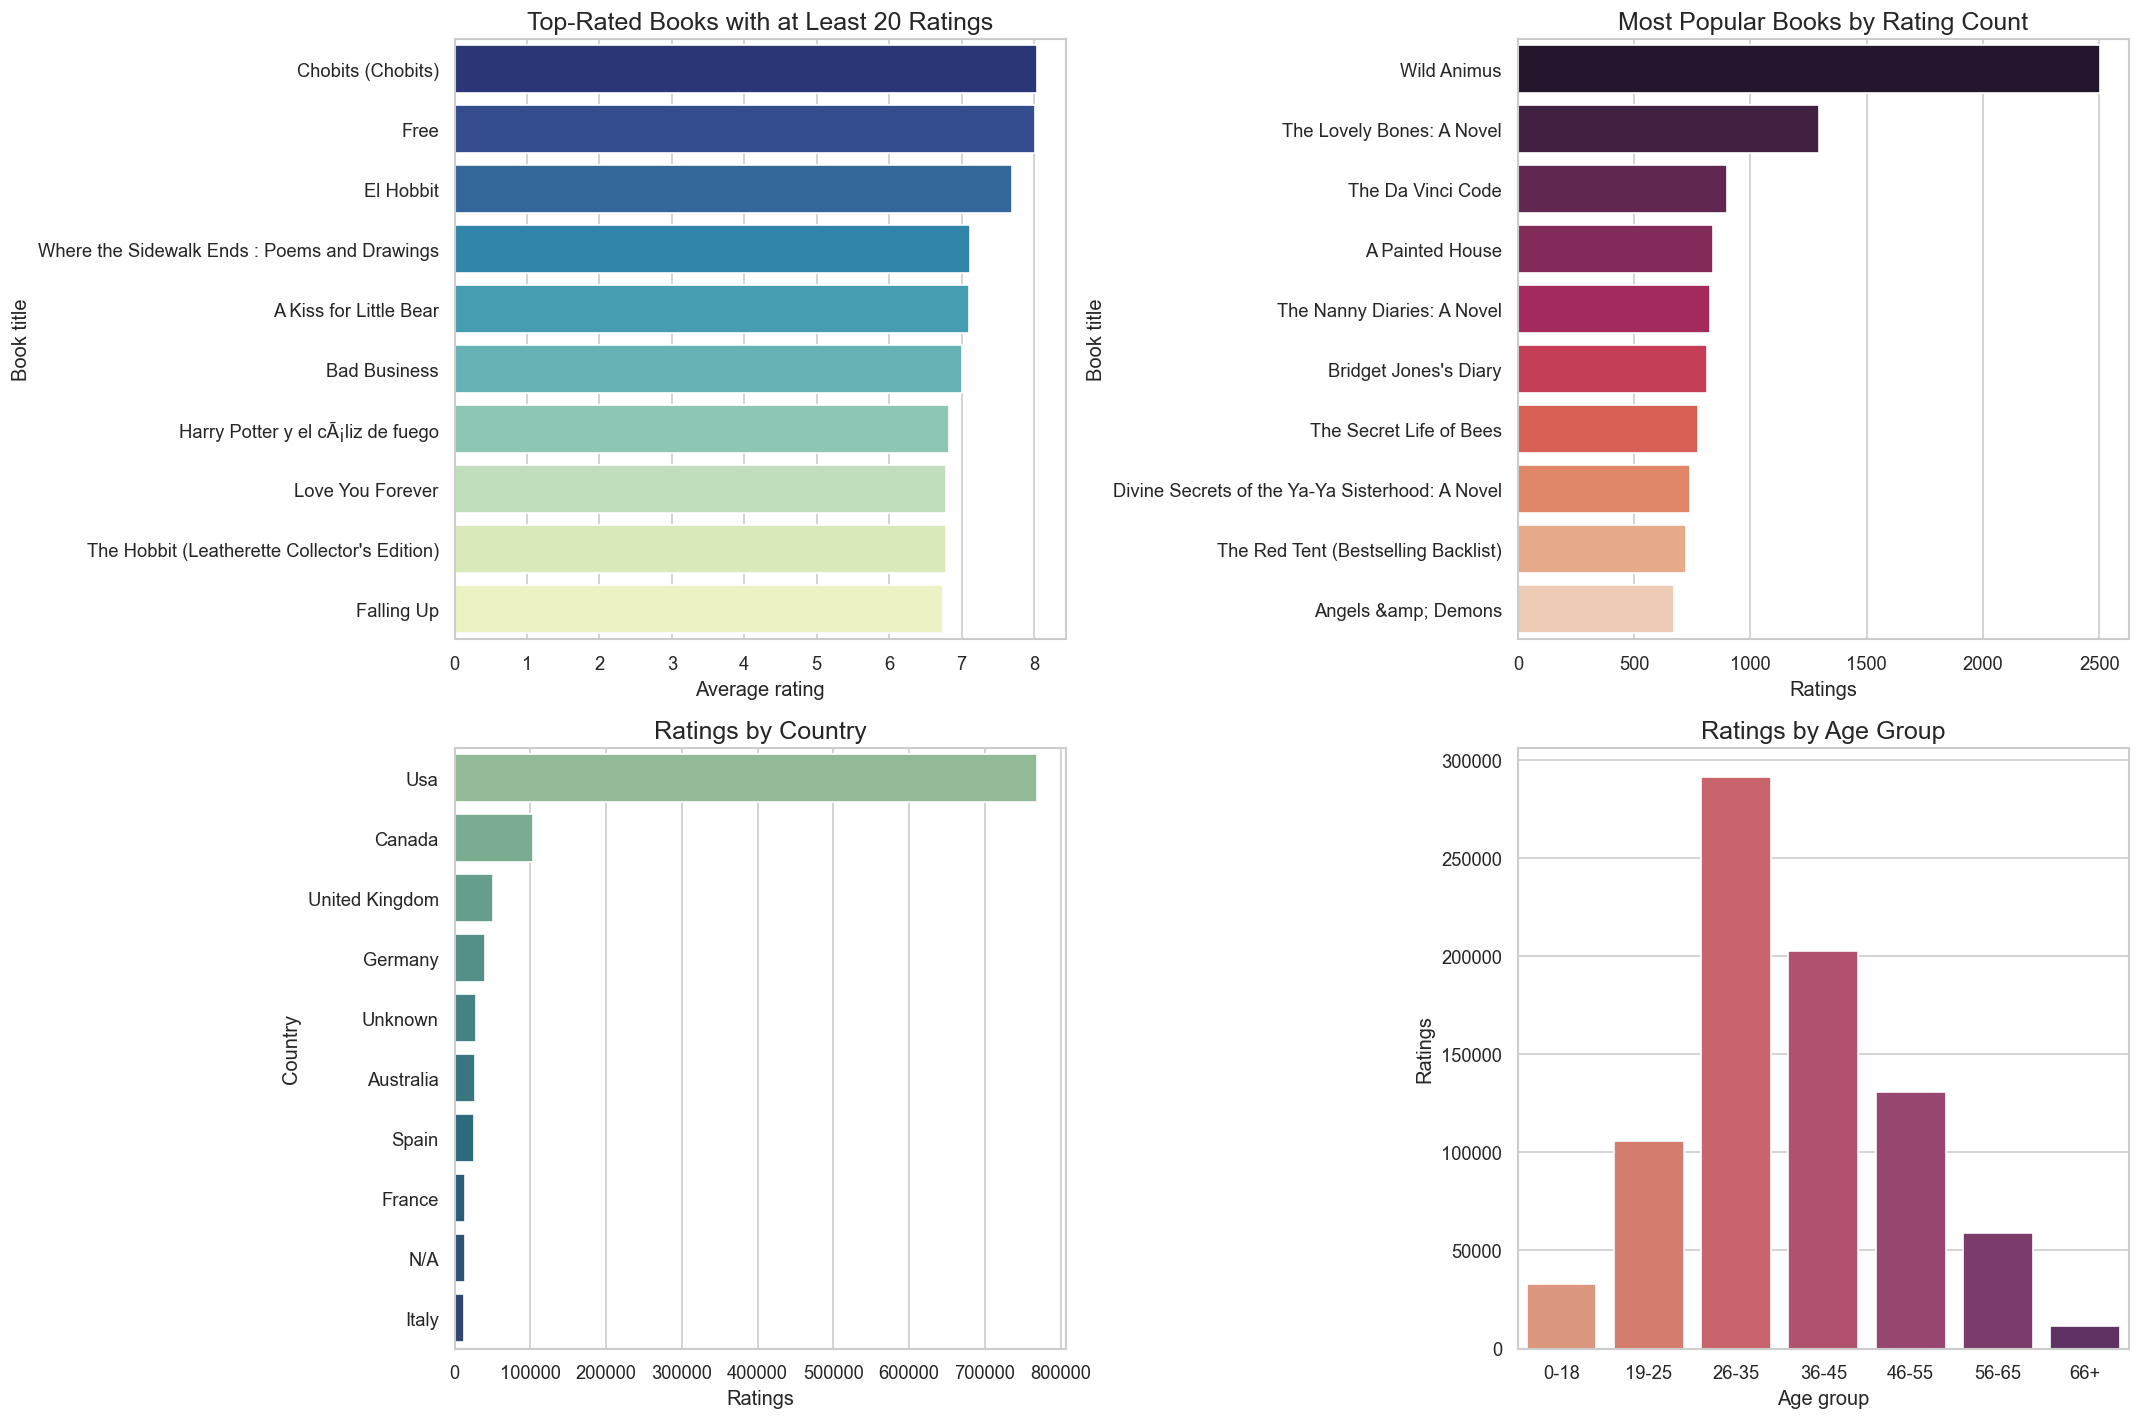

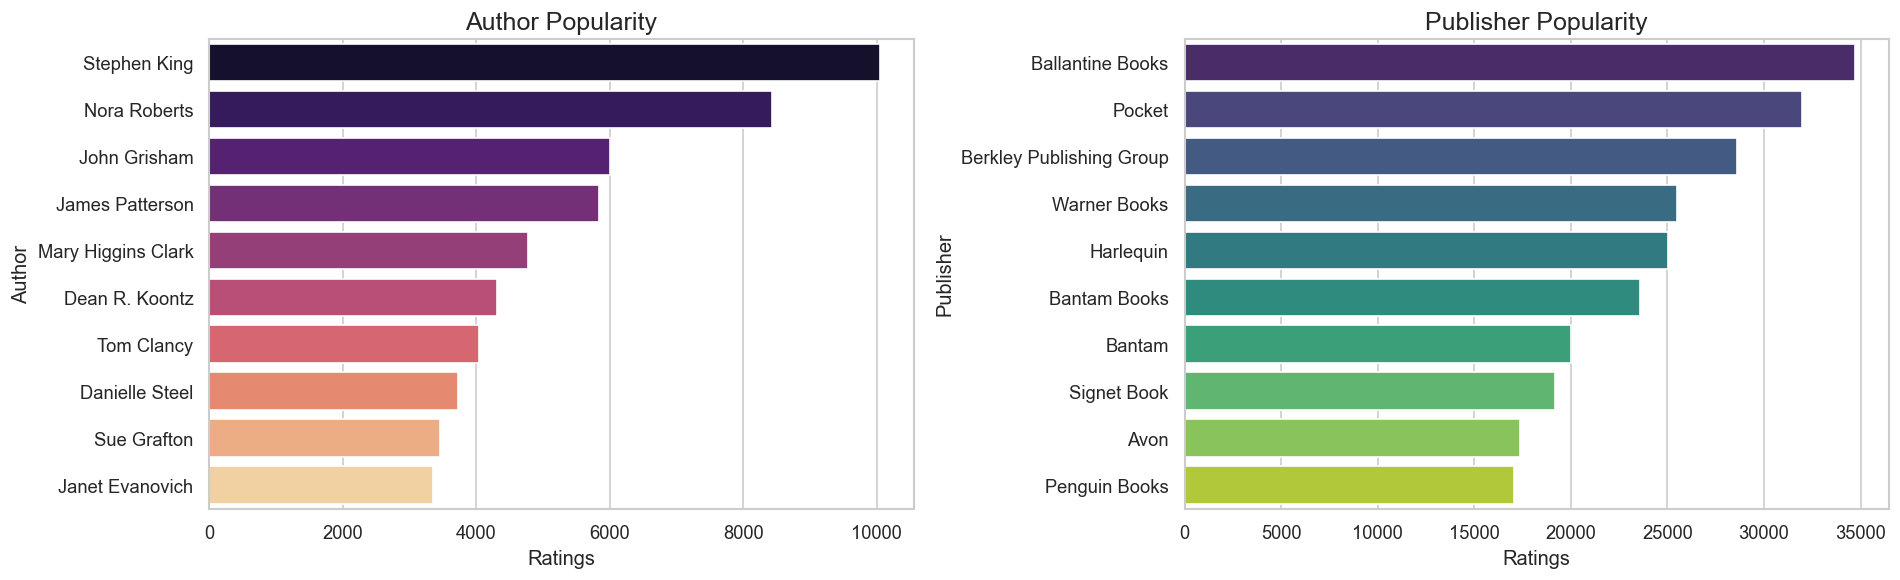

Combined section insights:
- Merging the tables allows analysis of engagement by demographic group, author, and publisher.
- Top-rated books should be filtered by a minimum rating count so the average is statistically stable.
- Country and age-group views reveal whether popularity differs across user segments.

7. Correlation and Statistical Analysis


,Book_Rating,Age_Clean,Year_Clean
Book_Rating,1.000000,-0.019603,0.039076
Age_Clean,-0.019603,1.000000,-0.017663
Year_Clean,0.039076,-0.017663,1.000000


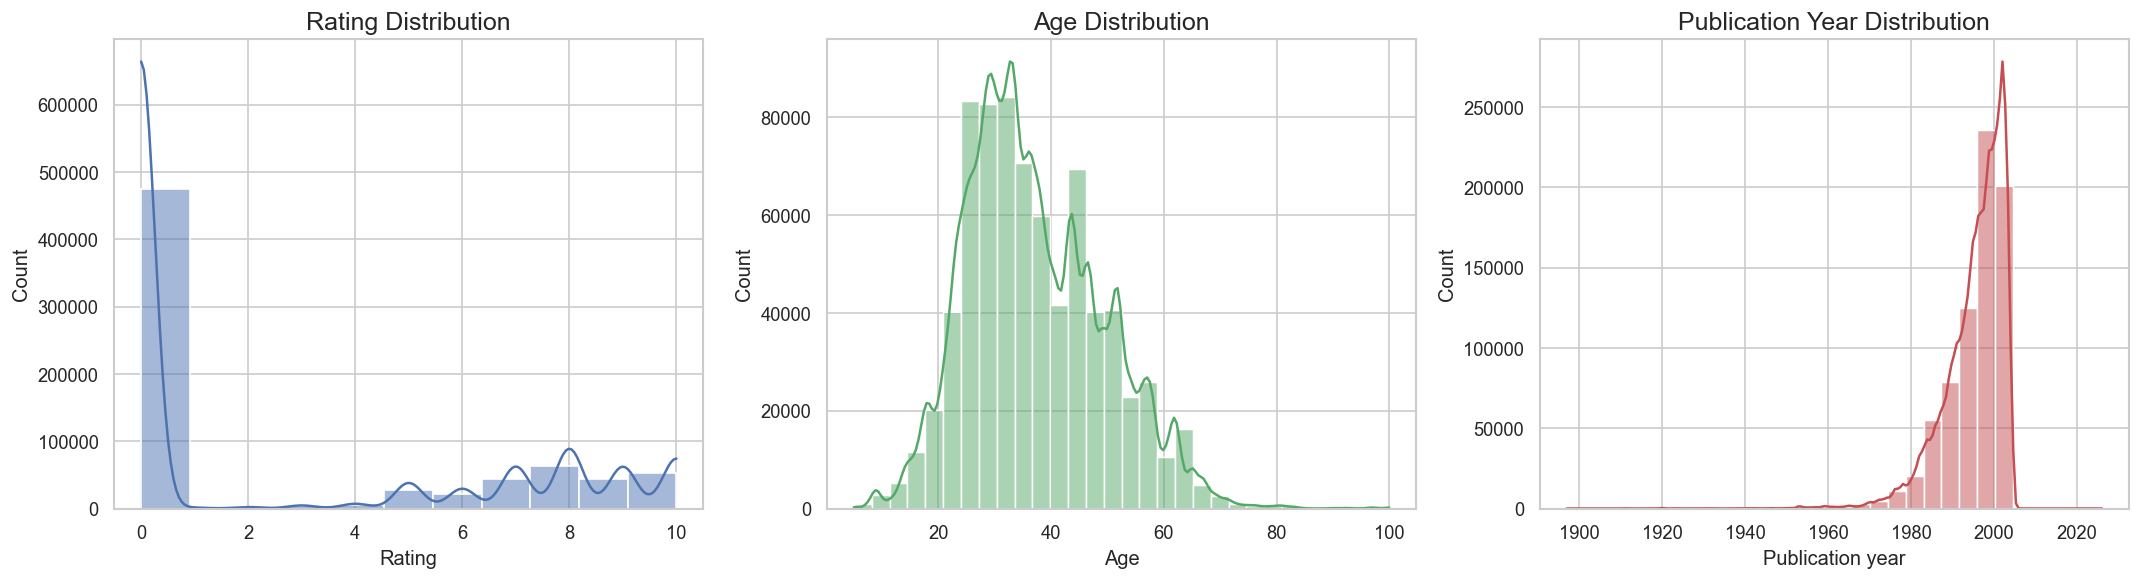

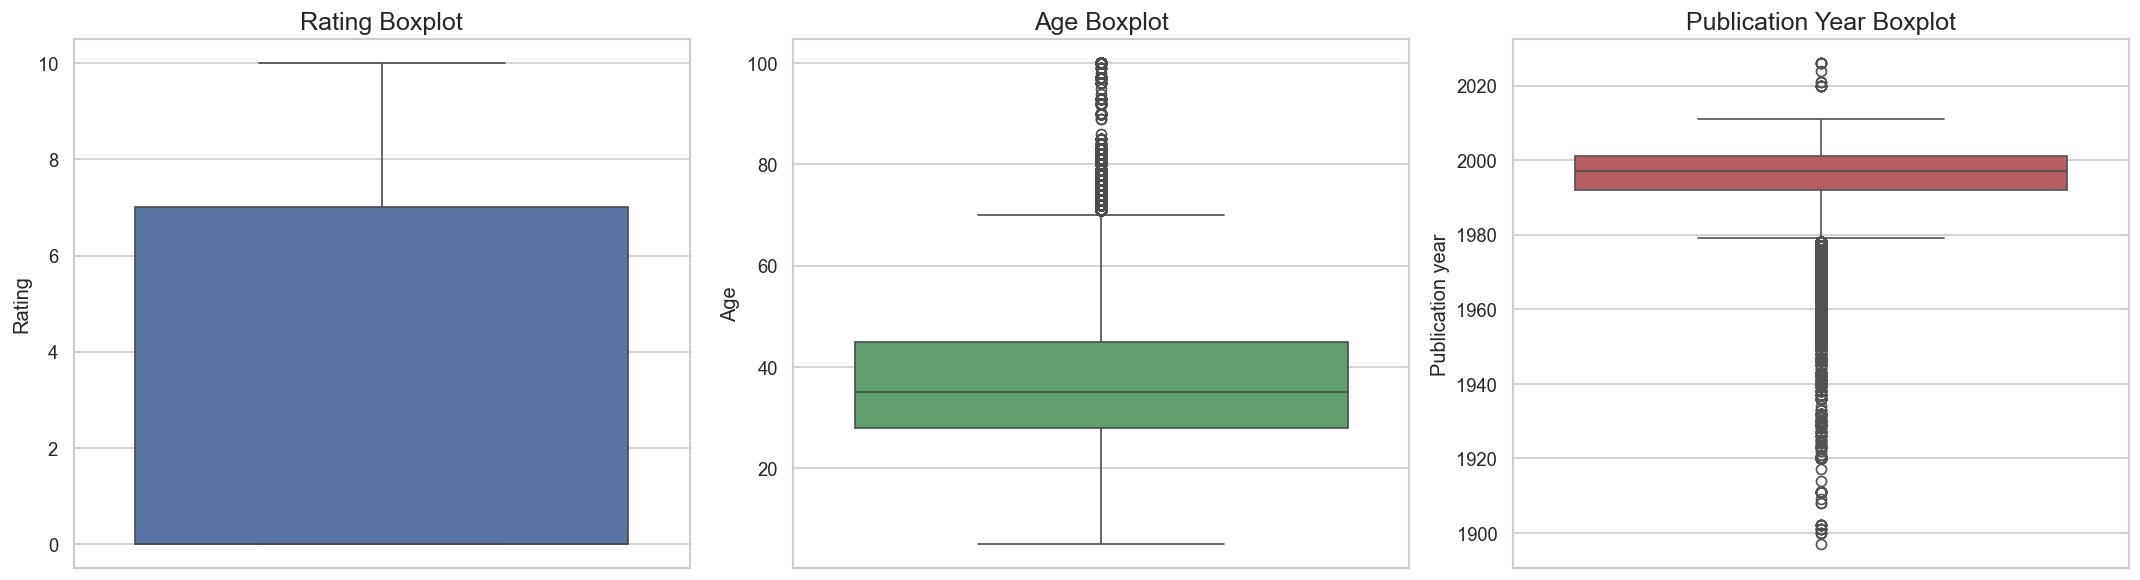

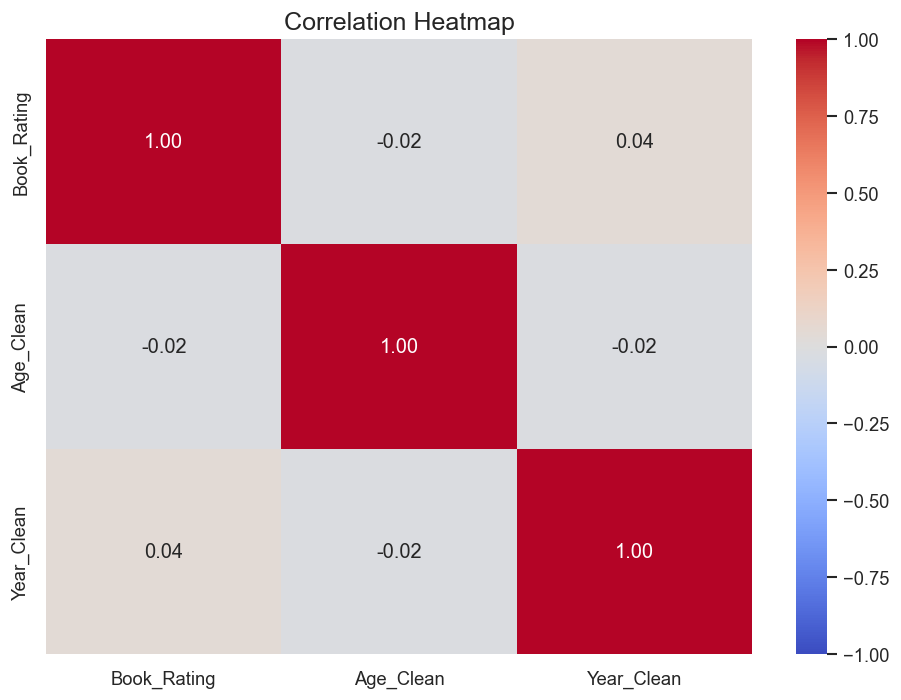

Statistical insights:
- Correlations should be interpreted carefully because recommendation data is usually sparse and skewed.
- Boxplots help identify extreme ages or unusual publication years before model training.
- Ratings are often more useful as interaction strength than as a strongly correlated continuous feature.

8. Graph Recommendation Analysis


,metric,value
0,User nodes,1.052830e+05
1,Book nodes,3.405560e+05
2,Edges,1.149780e+06
3,Average degree,5.157826e+00


,node,degree,type
5063,user_11676,13602,user
75665,user_198711,7550,user
58963,user_153662,6109,user
38206,user_98391,5891,user
14426,user_35859,5850,user
81035,user_212898,4785,user
678,user_278418,4533,user
29734,user_76352,3367,user
42887,user_110973,3100,user
89434,user_235105,3067,user


,node,degree,type
105735,book_0971880107,2502,book
105704,book_0316666343,1295,book
105707,book_0385504209,883,book
108119,book_0060928336,732,book
106648,book_0312195516,723,book
106525,book_044023722X,647,book
106618,book_0679781587,639,book
106747,book_0142001740,615,book
108115,book_067976402X,614,book
107199,book_0671027360,586,book


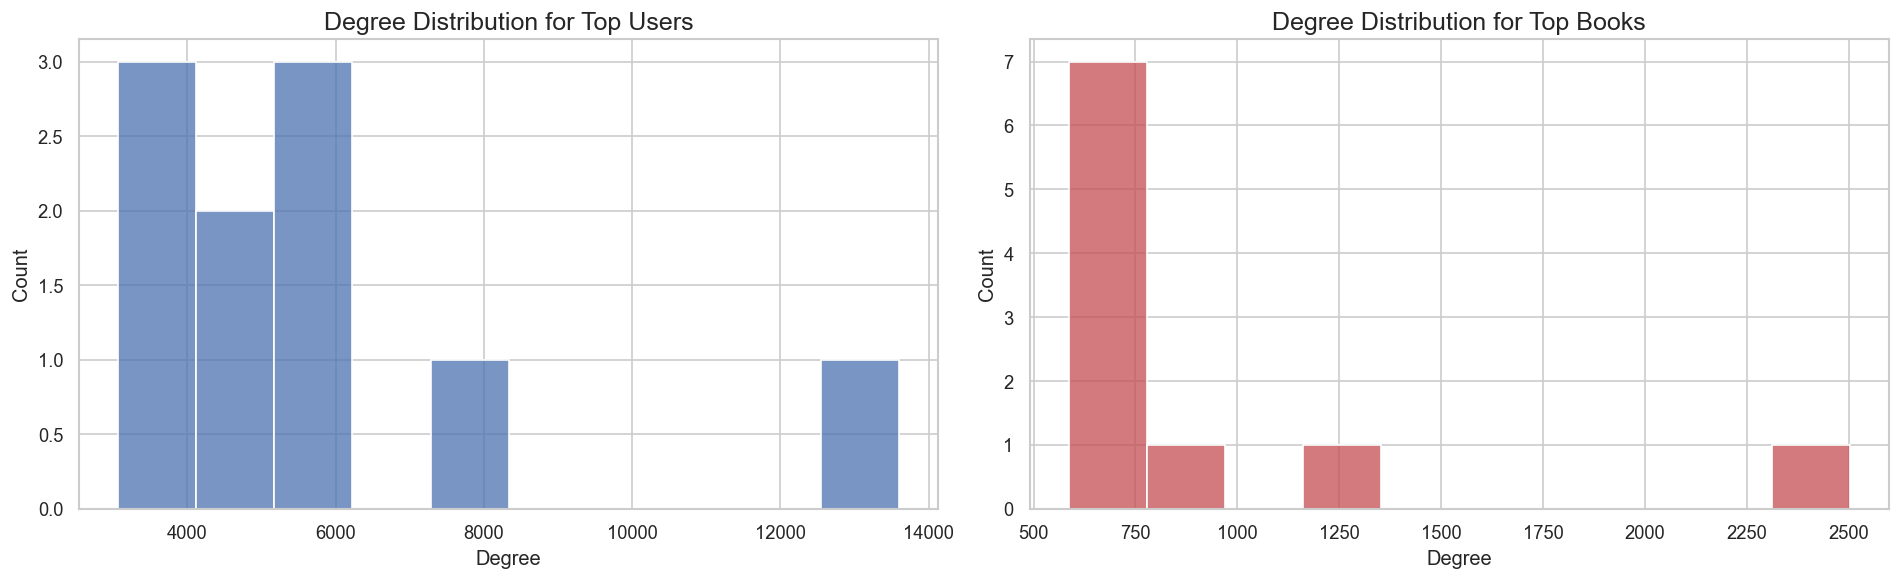

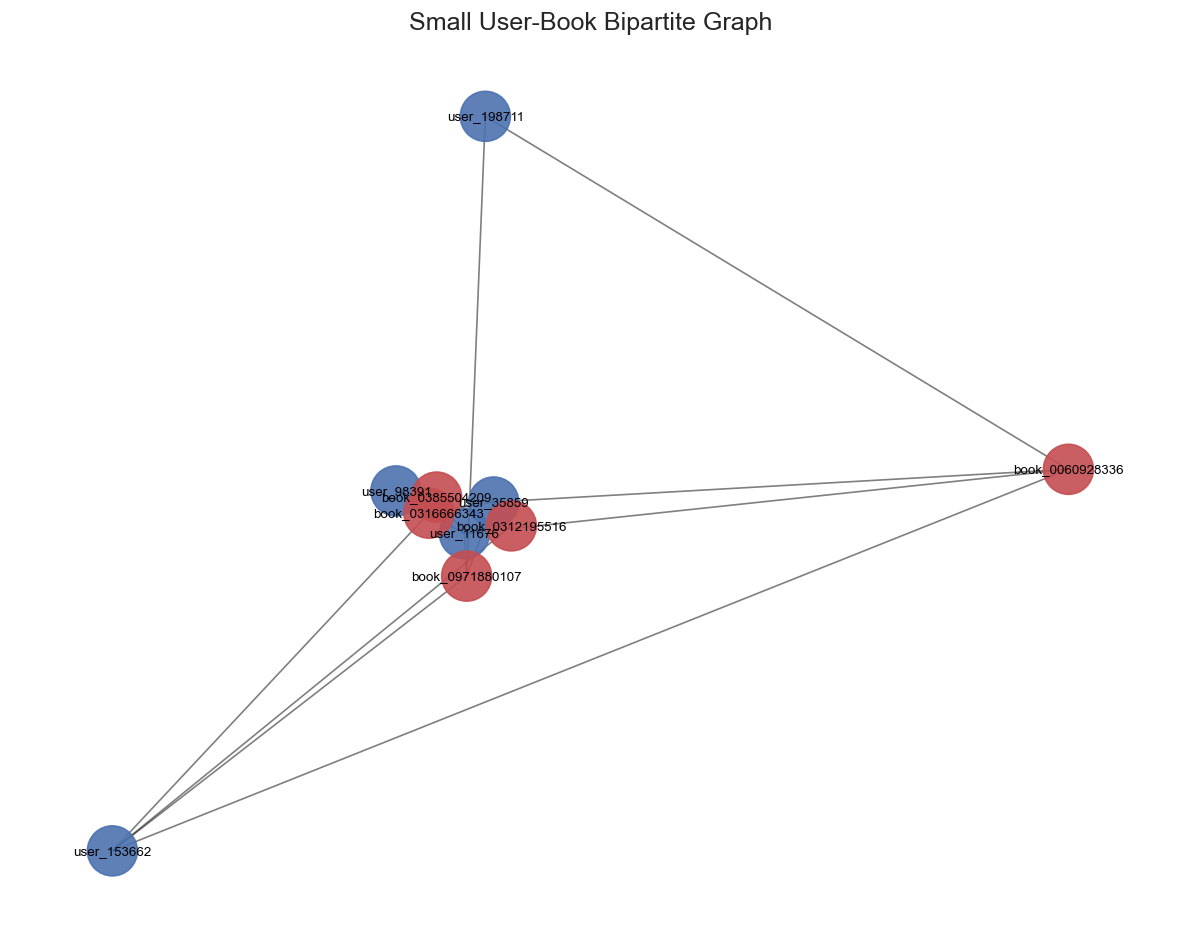

Graph section insights:
- Each user-book rating becomes an interaction edge in the recommendation graph.
- High-degree users and books act as hubs and strongly influence collaborative filtering behavior.
- Bipartite graph structure is the basis for message passing or embedding learning in graph recommenders.

9. Feature Engineering Suggestions


,area,recommendation
0,User nodes,"Age_Clean, Country, rating count, mean rating,..."
1,Book nodes,"Book-Author, Publisher, Year-Of-Publication_Cl..."
2,Edge features,"Book-Rating, explicit or implicit flag, intera..."
3,Columns to remove,"Image-URL-S, Image-URL-M, Image-URL-L and any ..."
4,Columns to encode,"Country, Book-Author, Publisher, age group, an..."
5,Data cleaning before graph construction,"Remove invalid years, unrealistic ages, duplic..."



10. Final Summary


,topic,summary
0,Data quality,"Missing ages, invalid years, and foreign-key m..."
1,Catalog structure,Book metadata is dominated by a long tail of a...
2,User behavior,Age and country information can be used as use...
3,Rating behavior,"Ratings are sparse and skewed, so the user-boo..."
4,Graph recommendation takeaway,The user-book bipartite graph should be built ...


Recommended preprocessing pipeline:
1. Re-read raw CSV files and preserve original columns for auditing.
2. Remove invalid years, unrealistic ages, duplicate rows, and out-of-range ratings.
3. Standardize categorical strings and extract country from location.
4. Build user and book node tables, then create the bipartite edge list from cleaned ratings.
5. Generate node and edge features for the graph model and split data for training and evaluation.
6. Save cleaned tables and graph artifacts for downstream recommender training.


In [4]:
section_title('6. Combined Dataset Analysis')

merged = (
    ratings_clean
    .merge(books_clean, on='ISBN', how='left')
    .merge(users_clean[['User-ID', 'Location', 'Age', 'Age_Clean', 'Country']], on='User-ID', how='left')
)

merged['Age_Group'] = pd.cut(
    merged['Age_Clean'],
    bins=[0, 18, 25, 35, 45, 55, 65, np.inf],
    labels=['0-18', '19-25', '26-35', '36-45', '46-55', '56-65', '66+'],
    include_lowest=True,
)

combined_summary = pd.DataFrame({
    'metric': ['Merged rows', 'Unique users', 'Unique books', 'Unique countries'],
    'value': [
        len(merged),
        merged['User-ID'].nunique(),
        merged['ISBN'].nunique(),
        merged['Country'].nunique(),
    ],
})
display(combined_summary)

book_group = merged.groupby('Book-Title').agg(
    average_rating=('Book-Rating', 'mean'),
    rating_count=('Book-Rating', 'size')
).reset_index()

top_rated_books = (
    book_group.loc[book_group['rating_count'] >= 20]
    .sort_values(['average_rating', 'rating_count'], ascending=[False, False])
    .head(10)
)

popular_books = book_group.sort_values('rating_count', ascending=False).head(10)
country_ratings = merged.groupby('Country').agg(
    avg_rating=('Book-Rating', 'mean'),
    rating_count=('Book-Rating', 'size')
).sort_values('rating_count', ascending=False).head(10).reset_index()
age_group_ratings = merged.groupby('Age_Group').agg(
    avg_rating=('Book-Rating', 'mean'),
    rating_count=('Book-Rating', 'size')
).reset_index()
author_popularity = merged.groupby('Book-Author').agg(
    rating_count=('Book-Rating', 'size'),
    avg_rating=('Book-Rating', 'mean')
).sort_values('rating_count', ascending=False).head(10).reset_index()
publisher_popularity = merged.groupby('Publisher').agg(
    rating_count=('Book-Rating', 'size'),
    avg_rating=('Book-Rating', 'mean')
).sort_values('rating_count', ascending=False).head(10).reset_index()

display(top_rated_books)
display(popular_books)
display(country_ratings)
display(age_group_ratings)
display(author_popularity)
display(publisher_popularity)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.barplot(data=top_rated_books, x='average_rating', y='Book-Title', ax=axes[0, 0], palette='YlGnBu_r')
axes[0, 0].set_title('Top-Rated Books with at Least 20 Ratings')
axes[0, 0].set_xlabel('Average rating')
axes[0, 0].set_ylabel('Book title')

sns.barplot(data=popular_books, x='rating_count', y='Book-Title', ax=axes[0, 1], palette='rocket')
axes[0, 1].set_title('Most Popular Books by Rating Count')
axes[0, 1].set_xlabel('Ratings')
axes[0, 1].set_ylabel('Book title')

sns.barplot(data=country_ratings, x='rating_count', y='Country', ax=axes[1, 0], palette='crest')
axes[1, 0].set_title('Ratings by Country')
axes[1, 0].set_xlabel('Ratings')
axes[1, 0].set_ylabel('Country')

sns.barplot(data=age_group_ratings, x='Age_Group', y='rating_count', ax=axes[1, 1], palette='flare')
axes[1, 1].set_title('Ratings by Age Group')
axes[1, 1].set_xlabel('Age group')
axes[1, 1].set_ylabel('Ratings')

save_current_fig('combined_analysis.png')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=author_popularity, x='rating_count', y='Book-Author', ax=axes[0], palette='magma')
axes[0].set_title('Author Popularity')
axes[0].set_xlabel('Ratings')
axes[0].set_ylabel('Author')

sns.barplot(data=publisher_popularity, x='rating_count', y='Publisher', ax=axes[1], palette='viridis')
axes[1].set_title('Publisher Popularity')
axes[1].set_xlabel('Ratings')
axes[1].set_ylabel('Publisher')

save_current_fig('author_publisher_popularity.png')
plt.show()

print('Combined section insights:')
print('- Merging the tables allows analysis of engagement by demographic group, author, and publisher.')
print('- Top-rated books should be filtered by a minimum rating count so the average is statistically stable.')
print('- Country and age-group views reveal whether popularity differs across user segments.')

section_title('7. Correlation and Statistical Analysis')

stat_df = merged[['Book-Rating', 'Age_Clean', 'Year-Of-Publication_Clean']].dropna().copy()
stat_df.columns = ['Book_Rating', 'Age_Clean', 'Year_Clean']

correlation_matrix = stat_df.corr(numeric_only=True)
display(correlation_matrix)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(stat_df['Book_Rating'], bins=11, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

sns.histplot(stat_df['Age_Clean'], bins=30, kde=True, ax=axes[1], color='#55A868')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

sns.histplot(stat_df['Year_Clean'], bins=30, kde=True, ax=axes[2], color='#C44E52')
axes[2].set_title('Publication Year Distribution')
axes[2].set_xlabel('Publication year')
axes[2].set_ylabel('Count')

save_current_fig('statistical_distributions.png')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y=stat_df['Book_Rating'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Rating Boxplot')
axes[0].set_xlabel('')
axes[0].set_ylabel('Rating')

sns.boxplot(y=stat_df['Age_Clean'], ax=axes[1], color='#55A868')
axes[1].set_title('Age Boxplot')
axes[1].set_xlabel('')
axes[1].set_ylabel('Age')

sns.boxplot(y=stat_df['Year_Clean'], ax=axes[2], color='#C44E52')
axes[2].set_title('Publication Year Boxplot')
axes[2].set_xlabel('')
axes[2].set_ylabel('Publication year')

save_current_fig('statistical_boxplots.png')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Heatmap')
save_current_fig('correlation_heatmap.png')
plt.show()

print('Statistical insights:')
print('- Correlations should be interpreted carefully because recommendation data is usually sparse and skewed.')
print('- Boxplots help identify extreme ages or unusual publication years before model training.')
print('- Ratings are often more useful as interaction strength than as a strongly correlated continuous feature.')

section_title('8. Graph Recommendation Analysis')

graph_edges = ratings_clean[['User-ID', 'ISBN', 'Book-Rating']].dropna().drop_duplicates(subset=['User-ID', 'ISBN']).copy()
graph_edges['user_node'] = 'user_' + graph_edges['User-ID'].astype(str)
graph_edges['book_node'] = 'book_' + graph_edges['ISBN'].astype(str)

G = nx.Graph()
G.add_nodes_from(graph_edges['user_node'].unique(), bipartite='users')
G.add_nodes_from(graph_edges['book_node'].unique(), bipartite='books')
G.add_edges_from(
    (row['user_node'], row['book_node'], {'weight': row['Book-Rating']})
    for _, row in graph_edges.iterrows()
)

user_nodes = [node for node, data in G.nodes(data=True) if data.get('bipartite') == 'users']
book_nodes = [node for node, data in G.nodes(data=True) if data.get('bipartite') == 'books']

node_degree = pd.DataFrame(G.degree(), columns=['node', 'degree'])
node_degree['type'] = np.where(node_degree['node'].str.startswith('user_'), 'user', 'book')
user_degree = node_degree[node_degree['type'] == 'user'].sort_values('degree', ascending=False).head(10)
book_degree = node_degree[node_degree['type'] == 'book'].sort_values('degree', ascending=False).head(10)

graph_metrics = pd.DataFrame({
    'metric': ['User nodes', 'Book nodes', 'Edges', 'Average degree'],
    'value': [len(user_nodes), len(book_nodes), G.number_of_edges(), (2 * G.number_of_edges()) / G.number_of_nodes()],
})
display(graph_metrics)
display(user_degree)
display(book_degree)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(user_degree['degree'], bins=10, ax=axes[0], color='#4C72B0')
axes[0].set_title('Degree Distribution for Top Users')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')

sns.histplot(book_degree['degree'], bins=10, ax=axes[1], color='#C44E52')
axes[1].set_title('Degree Distribution for Top Books')
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('Count')

save_current_fig('graph_degree_distribution.png')
plt.show()

small_user_nodes = user_degree['node'].head(5).tolist()
small_book_nodes = book_degree['node'].head(5).tolist()
small_nodes = small_user_nodes + small_book_nodes
small_graph = G.subgraph(small_nodes).copy()
positions = nx.spring_layout(small_graph, seed=42)
node_colors = ['#4C72B0' if node.startswith('user_') else '#C44E52' for node in small_graph.nodes()]

plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(small_graph, positions, node_color=node_colors, node_size=900, alpha=0.9)
nx.draw_networkx_edges(small_graph, positions, alpha=0.5)
nx.draw_networkx_labels(small_graph, positions, font_size=8)
plt.title('Small User-Book Bipartite Graph')
plt.axis('off')
save_current_fig('small_bipartite_graph.png')
plt.show()

print('Graph section insights:')
print('- Each user-book rating becomes an interaction edge in the recommendation graph.')
print('- High-degree users and books act as hubs and strongly influence collaborative filtering behavior.')
print('- Bipartite graph structure is the basis for message passing or embedding learning in graph recommenders.')

section_title('9. Feature Engineering Suggestions')

feature_suggestions = pd.DataFrame({
    'area': ['User nodes', 'Book nodes', 'Edge features', 'Columns to remove', 'Columns to encode', 'Data cleaning before graph construction'],
    'recommendation': [
        'Age_Clean, Country, rating count, mean rating, implicit rating ratio, activity level',
        'Book-Author, Publisher, Year-Of-Publication_Clean, average rating, rating count, popularity score',
        'Book-Rating, explicit or implicit flag, interaction weight, time-derived features if available',
        'Image-URL-S, Image-URL-M, Image-URL-L and any unused free-text columns that do not add graph signal',
        'Country, Book-Author, Publisher, age group, and categorical popularity bins',
        'Remove invalid years, unrealistic ages, duplicate interactions, and out-of-range ratings; standardize string fields and fill missing categories with Unknown',
    ],
})
display(feature_suggestions)

section_title('10. Final Summary')

final_summary = pd.DataFrame({
    'topic': ['Data quality', 'Catalog structure', 'User behavior', 'Rating behavior', 'Graph recommendation takeaway'],
    'summary': [
        'Missing ages, invalid years, and foreign-key mismatches must be resolved before graph construction.',
        'Book metadata is dominated by a long tail of authors and publishers, so popularity bias is expected.',
        'Age and country information can be used as user-side features after cleaning.',
        'Ratings are sparse and skewed, so the user-book graph will be highly sparse and interaction-driven.',
        'The user-book bipartite graph should be built from cleaned unique interactions and can then feed a graph embedding model.',
    ],
})
display(final_summary)

print('Recommended preprocessing pipeline:')
print('1. Re-read raw CSV files and preserve original columns for auditing.')
print('2. Remove invalid years, unrealistic ages, duplicate rows, and out-of-range ratings.')
print('3. Standardize categorical strings and extract country from location.')
print('4. Build user and book node tables, then create the bipartite edge list from cleaned ratings.')
print('5. Generate node and edge features for the graph model and split data for training and evaluation.')
print('6. Save cleaned tables and graph artifacts for downstream recommender training.')


## 11. Report-Ready Key Findings

- The books catalog is highly skewed: a small set of authors and publishers contribute a large share of the inventory.
- The users table has substantial age missingness, and the cleaned age distribution is concentrated around young to middle-aged users.
- Ratings are strongly imbalanced toward implicit feedback (`0`), so popularity bias will be a major factor in model behavior.
- The merged analysis shows clear concentration by country, age group, author, and publisher, which can be exploited as side information.
- Correlations among rating, age, and publication year are weak, which is expected for sparse recommendation data.
- The user-book graph is sparse but well-suited for bipartite message passing, with a few high-degree hub users and books dominating connectivity.

In [7]:
section_title('12. Export Cleaned Artifacts for Training')

import sys

repo_root = PROJECT_ROOT
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.book_reco.graph_construction import (
    build_edge_tables,
    compute_graph_statistics,
    create_node_mappings,
    save_lightgcn_tensors,
    save_tabular_outputs,
)

processed_dir = PROJECT_ROOT / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

books_clean.to_csv(processed_dir / 'books_clean_eda.csv', index=False)
users_clean.to_csv(processed_dir / 'users_clean_eda.csv', index=False)
ratings_clean.to_csv(processed_dir / 'ratings_clean_eda.csv', index=False)
merged.to_csv(processed_dir / 'merged_eda.csv', index=False)

eda_interactions = ratings_clean[['User-ID', 'ISBN', 'Book-Rating']].drop_duplicates().copy()
eda_interactions.to_csv(processed_dir / 'cleaned_ratings.csv', index=False)
eda_interactions.to_csv(processed_dir / 'cleaned_ratings_from_eda.csv', index=False)

user_mapping, book_mapping = create_node_mappings(eda_interactions)
edge_index, edge_weight = build_edge_tables(eda_interactions, user_mapping, book_mapping)
num_users, num_books, num_nodes, num_edges, average_degree, graph_density = compute_graph_statistics(
    eda_interactions,
    user_mapping,
    book_mapping,
    edge_index,
)

save_tabular_outputs(user_mapping, book_mapping, edge_index, edge_weight, output_dir=processed_dir)
lightgcn_path = save_lightgcn_tensors(edge_index, edge_weight, num_nodes, output_dir=processed_dir)

export_summary = pd.DataFrame(
    {
        'artifact': [
            'books_clean_eda.csv',
            'users_clean_eda.csv',
            'ratings_clean_eda.csv',
            'merged_eda.csv',
            'cleaned_ratings.csv',
            'cleaned_ratings_from_eda.csv',
            'user_mapping.csv',
            'book_mapping.csv',
            'edge_index.csv',
            'edge_weight.csv',
            'lightgcn_graph.pt',
        ],
        'saved_to': [
            processed_dir / 'books_clean_eda.csv',
            processed_dir / 'users_clean_eda.csv',
            processed_dir / 'ratings_clean_eda.csv',
            processed_dir / 'merged_eda.csv',
            processed_dir / 'cleaned_ratings.csv',
            processed_dir / 'cleaned_ratings_from_eda.csv',
            processed_dir / 'user_mapping.csv',
            processed_dir / 'book_mapping.csv',
            processed_dir / 'edge_index.csv',
            processed_dir / 'edge_weight.csv',
            lightgcn_path if lightgcn_path is not None else processed_dir / 'lightgcn_graph.pt',
        ],
    }
)

graph_summary = pd.DataFrame(
    {
        'metric': ['User nodes', 'Book nodes', 'Edges', 'Average degree', 'Graph density'],
        'value': [num_users, num_books, num_edges, round(average_degree, 4), round(graph_density, 8)],
    }
)

display(graph_summary)
display(export_summary)

print('Export complete. The EDA-derived tables and graph artifacts were written to data/processed for reuse in downstream experiments.')


12. Export Cleaned Artifacts for Training


,metric,value
0,User nodes,1.052830e+05
1,Book nodes,3.405560e+05
2,Edges,1.149780e+06
3,Average degree,5.157800e+00
4,Graph density,3.207000e-05


,artifact,saved_to
0,books_clean_eda.csv,D:\Semester-Wise-Materials\sixth_sem\recommend...
1,users_clean_eda.csv,D:\Semester-Wise-Materials\sixth_sem\recommend...
2,ratings_clean_eda.csv,D:\Semester-Wise-Materials\sixth_sem\recommend...
3,merged_eda.csv,D:\Semester-Wise-Materials\sixth_sem\recommend...
4,cleaned_ratings.csv,D:\Semester-Wise-Materials\sixth_sem\recommend...
5,cleaned_ratings_from_eda.csv,D:\Semester-Wise-Materials\sixth_sem\recommend...
6,user_mapping.csv,D:\Semester-Wise-Materials\sixth_sem\recommend...
7,book_mapping.csv,D:\Semester-Wise-Materials\sixth_sem\recommend...
8,edge_index.csv,D:\Semester-Wise-Materials\sixth_sem\recommend...
9,edge_weight.csv,D:\Semester-Wise-Materials\sixth_sem\recommend...


Export complete. The EDA-derived tables and graph artifacts were written to data/processed for reuse in downstream experiments.
